<a href="https://colab.research.google.com/github/GeemaInduruwage/computer-vision-assignment-1/blob/main/Question_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 7: Image Zooming with Interpolation

Write a program to zoom images by a given factor $s \in (0,10]$. You must use a function to zoom the image, which can handle:

(a) nearest-neighbor, and
(b) bilinear interpolation.

I have included several images, large originals, and their zoomed-out versions. Test your algorithm by computing the normalized sum of squared difference (SSD) when you scale-up the given small images to match the size of the large original images. The SSD should be small when comparing with the original images.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def zoom_image(image, scale_factor, interpolation_method='nearest'):
    """
    Zooms an image by a given scale factor using specified interpolation method.

    Args:
        image (np.array): The input image (H, W, C).
        scale_factor (float): The factor by which to zoom the image.
        interpolation_method (str): 'nearest' for nearest-neighbor or 'bilinear' for bilinear interpolation.

    Returns:
        np.array: The zoomed image.
    """
    original_height, original_width, num_channels = image.shape
    new_height = int(original_height * scale_factor)
    new_width = int(original_width * scale_factor)

    # Create an empty array for the zoomed image
    zoomed_image = np.zeros((new_height, new_width, num_channels), dtype=image.dtype)

    if interpolation_method == 'nearest':
        for y_new in range(new_height):
            for x_new in range(new_width):
                # Map new coordinates back to original image coordinates
                # Use min to handle potential floating point issues near boundaries
                src_x = min(int(x_new / scale_factor), original_width - 1)
                src_y = min(int(y_new / scale_factor), original_height - 1)
                zoomed_image[y_new, x_new] = image[src_y, src_x]

    elif interpolation_method == 'bilinear':
        for y_new in range(new_height):
            for x_new in range(new_width):
                # Map new coordinates back to original image (float coordinates)
                src_x_float = x_new / scale_factor
                src_y_float = y_new / scale_factor

                # Find the four surrounding pixels in the original image
                x1 = int(src_x_float)
                y1 = int(src_y_float)

                # Ensure indices are within bounds
                x1 = max(0, min(x1, original_width - 1))
                y1 = max(0, min(y1, original_height - 1))
                x2 = min(x1 + 1, original_width - 1)
                y2 = min(y1 + 1, original_height - 1)

                # Calculate fractional parts
                dx = src_x_float - x1
                dy = src_y_float - y1

                for c in range(num_channels):
                    # Get pixel values of the four neighbors
                    q11 = image[y1, x1, c]
                    q12 = image[y2, x1, c]
                    q21 = image[y1, x2, c]
                    q22 = image[y2, x2, c]

                    # Perform bilinear interpolation
                    # Interpolate along x-axis
                    r1 = q11 * (1 - dx) + q21 * dx
                    r2 = q12 * (1 - dx) + q22 * dx

                    # Interpolate along y-axis
                    pixel_value = r1 * (1 - dy) + r2 * dy
                    zoomed_image[y_new, x_new, c] = pixel_value

    else:
        raise ValueError("Interpolation method must be 'nearest' or 'bilinear'")

    return zoomed_image

def calculate_normalized_ssd(image1, image2):
    """
    Calculates the normalized Sum of Squared Differences (SSD) between two images.
    Images are assumed to be of the same dimensions and type.

    Args:
        image1 (np.array): The first image.
        image2 (np.array): The second image.

    Returns:
        float: The normalized SSD.
    """
    if image1.shape != image2.shape:
        raise ValueError("Images must have the same dimensions for SSD calculation.")

    # Convert images to float to prevent overflow during squaring
    img1_float = image1.astype(np.float64)
    img2_float = image2.astype(np.float64)

    diff = img1_float - img2_float
    ssd = np.sum(diff ** 2)

    # Normalize by the total number of pixels to get an average squared difference
    # This makes SSD less dependent on image size.
    normalized_ssd = ssd / image1.size

    return normalized_ssd

Original large image shape: (560, 1000, 3)
Small image shape: (28, 50, 3)
Calculated scale factor (s): 20.0
Zoomed Nearest-Neighbor image shape: (560, 1000, 3)
Zoomed Bilinear image shape: (560, 1000, 3)

Normalized SSD (Nearest-Neighbor): 485.8904
Normalized SSD (Bilinear): 654.5982


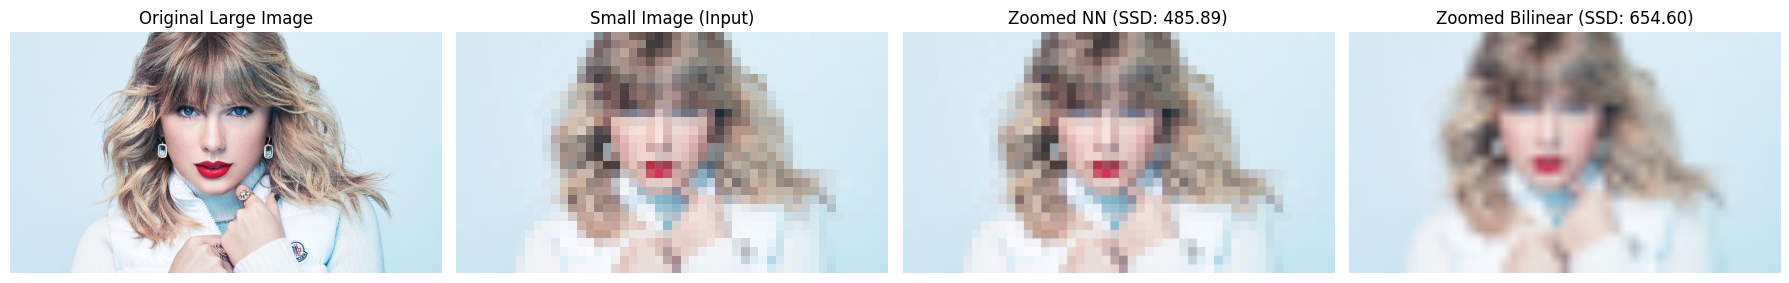

In [8]:
# Load the images
original_large_image_path = '/content/taylor.jpg'
small_image_path = '/content/taylor_very_small.jpg'

original_large_image = plt.imread(original_large_image_path)
small_image = plt.imread(small_image_path)

print(f"Original large image shape: {original_large_image.shape}")
print(f"Small image shape: {small_image.shape}")

# Calculate the required scale factor
scale_factor_height = original_large_image.shape[0] / small_image.shape[0]
scale_factor_width = original_large_image.shape[1] / small_image.shape[1]

if scale_factor_height != scale_factor_width:
    print("Warning: Aspect ratio mismatch. Using height scale factor.")
scale_factor = scale_factor_height

print(f"Calculated scale factor (s): {scale_factor}")

# Zoom the small image using nearest-neighbor interpolation
zoomed_nn_image = zoom_image(small_image, scale_factor, 'nearest')

# Zoom the small image using bilinear interpolation
zoomed_bilinear_image = zoom_image(small_image, scale_factor, 'bilinear')

print(f"Zoomed Nearest-Neighbor image shape: {zoomed_nn_image.shape}")
print(f"Zoomed Bilinear image shape: {zoomed_bilinear_image.shape}")

# Calculate normalized SSD for both interpolation methods
ssd_nn = calculate_normalized_ssd(original_large_image, zoomed_nn_image)
ssd_bilinear = calculate_normalized_ssd(original_large_image, zoomed_bilinear_image)

print(f"\nNormalized SSD (Nearest-Neighbor): {ssd_nn:.4f}")
print(f"Normalized SSD (Bilinear): {ssd_bilinear:.4f}")

# Display the images
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.imshow(original_large_image)
plt.title('Original Large Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(small_image)
plt.title('Small Image (Input)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(zoomed_nn_image)
plt.title(f'Zoomed NN (SSD: {ssd_nn:.2f})')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(zoomed_bilinear_image)
plt.title(f'Zoomed Bilinear (SSD: {ssd_bilinear:.2f})')
plt.axis('off')

plt.tight_layout()
plt.show()

### Why Nearest-Neighbor Might Result in Lower SSD than Bilinear

This is a great question, and it highlights an interesting aspect of image processing where numerical metrics don't always align perfectly with visual perception. Here's why nearest-neighbor might result in a lower SSD than bilinear, even if bilinear often *looks* better:

1.  **How SSD Works**: The Sum of Squared Differences (SSD) calculates the difference between corresponding pixels in two images, squares that difference, and then sums them up. A lower SSD means that the pixel values in the two images are, on average, numerically closer.

2.  **Nearest-Neighbor Interpolation**: This method is very simple. For every new pixel in the zoomed image, it simply picks the color of the *single closest pixel* from the original small image. It essentially replicates existing pixel values.
    *   **Impact on SSD**: Because it only copies existing pixel values, the resulting zoomed image will be blocky or pixelated. However, crucially, the pixel values it *does* use are directly from the original image. When you compare this blocky image to a high-resolution target image, if the target image also has somewhat 'sharp' or 'blocky' features (or if the original small image itself was a downsampled version that preserved distinct pixel values well), the nearest-neighbor values might, by chance, align more closely to the exact values present in the target image at some points, leading to smaller individual differences that sum up to a lower SSD.

3.  **Bilinear Interpolation**: This method is more sophisticated. For every new pixel, it calculates a *weighted average* of the four closest pixels from the original small image. This creates entirely *new* pixel values that are a blend of the surrounding ones.
    *   **Impact on SSD**: Bilinear interpolation produces a much smoother appearance because it's effectively blurring the image to fill in the gaps. However, because it's creating *new, averaged pixel values*, these values might deviate more from the *exact* pixel values of the original high-resolution target image, even if visually the transitions are smoother. The smoothing process can slightly shift colors or edges in a way that, while pleasing to the eye, results in larger squared differences when compared pixel-by-pixel to the original image's discrete values.

**In summary**: Nearest-neighbor preserves the exact (though repeated) pixel values of the source, which can sometimes lead to numerically smaller differences when compared to a target image's discrete values. Bilinear interpolation creates new, averaged pixel values, which, while visually smoother, might not align as perfectly numerically with the target image's pixel values, leading to a higher SSD. The SSD is a purely numerical metric and doesn't inherently account for perceived visual quality like smoothness.